# (노트) 다중공선성과 능형회귀
> 작성완료

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [응용통계]

### Motivation 

`-` 아래와 같은 가짜자료를 만들자. 

- 토익: $toeic \sim N(750,80^2)$
     - 990이 넘는 점수는 990으로 설정한다. 
     - 원래 토익점수는 정수로 나오지만 편의상 소수점도 있다고 하자. 
- 텝스: $teps = toeic + N(0,0.01^2)$
- GPA: $gpa \sim N(3.5,0.3^2)$
     - 4.5점이 넘는 것은 4.5로 설정 
     - gpa는 정수화한다. 
- 연봉: $sal = gpa \times 600 + toeic\times 5 + N(0,300^2)$

In [13]:
#collapse-hide
set.seed(999)
n<-20000
## 토익점수 
toeic<-750+rnorm(n,sd=80) 
toeic<-round(toeic) 
toeic[toeic>990]<-990 
## 텝스점수 
teps<-toeic + rnorm(n,sd=0.01) 
## GPA 
gpa<-3.5+rnorm(n,sd=0.3)
gpa[gpa>4.5]<-4.5 
gpa<-round(gpa,1)
## 연봉 
sal<-gpa*600+toeic*5+rnorm(n,sd=300)
sal<-round(sal)

In [14]:
cor(toeic,teps)

[1] 1

`-` 직관: 토익이나 텝스점수나 그게 그거이다. (강한 상관관계)

원래모형은 `연봉=학점*600+토익*5+오차`인데, 토익이나 텝스나 그게 그거이므로, 아래와 같은 모형들도 거의 참모형이라고 생각할 수 있다. 

(1) `연봉=학점*600+토익*2+텝스*3+오차`

(2) `연봉=학점*600+토익*1+텝스*4+오차`

(3) `연봉=학점*600+토익*(-5)+텝스*10+오차`

(4) `연봉=학점*600+토익*(-1000)+텝스*(1005)+오차`

(5) `연봉=학점*600+토익*(-10000)+텝스*(10005)+오차`

...

`-` 결국에는 토익의 계수와 텝스의 계수를 더해서 5만되면 참모형

`-` 이제 

$$sal = \beta_0 + \beta_1 toeic + \beta_2 teps + \beta_3 gpa + error$$ 

를 가정하고 회귀분석을 수행하여 보자. 

In [15]:
lm1<-lm(sal~toeic+teps+gpa)
lm1


Call:
lm(formula = sal ~ toeic + teps + gpa)

Coefficients:
(Intercept)        toeic         teps          gpa  
      50.38       194.70      -189.72       590.53  


토익의 계수는 194.70, 텝스의 계수는 -189.72 로 추정되었다. 두개더하면 대략 5.  

`-` set.seed()를 바꾸고 다시 가짜자료 생성 $\to$ 회귀분석을 수행하자. 

In [16]:
#collapse-hide
set.seed(1)
n<-20000
toeic<-750+rnorm(n,sd=80)
toeic[toeic>990]<-990
teps<-toeic + rnorm(n,sd=0.01)
gpa<-3.5+rnorm(n,sd=0.3)
gpa[gpa>4.5]<-4.5 
gpa<-round(gpa,1)
sal<-gpa*600+toeic*5+rnorm(n,sd=300)
sal<-round(sal)

In [17]:
lm(sal~toeic+teps+gpa)


Call:
lm(formula = sal ~ toeic + teps + gpa)

Coefficients:
(Intercept)        toeic         teps          gpa  
     -45.82       -64.84        69.87       606.31  


이번에는 토익의 계수는 -64.49, 텝스의 계수는 69.50 두개 더하면 대충 5

`-` set.seed()를 변경하고 다시 가짜자료 생성 $\to$ 회귀분석 수행

In [19]:
#collapse-hide
set.seed(2)
n<-20000
toeic<-750+rnorm(n,sd=80)
toeic[toeic>990]<-990
toeic<-round(toeic)
teps<-toeic + rnorm(n,sd=0.01)
gpa<-3.5+rnorm(n,sd=0.3)
gpa[gpa>4.5]<-4.5 
gpa<-round(gpa,1)
sal<-gpa*600+toeic*5+rnorm(n,sd=300)
sal<-round(sal)

In [24]:
lm(sal~toeic+teps+gpa)


Call:
lm(formula = sal ~ toeic + teps + gpa)

Coefficients:
(Intercept)        toeic         teps          gpa  
     -32.02      -152.82       157.85       600.85  


토익의 계수는 217.27, 텝스의 계수는 -212.31 두개더하면 대충 5

`-` set.seed()를 변경하고 다시 가짜자료 생성 $\to$ 회귀분석 수행

In [22]:
#collapse-hide
set.seed(3)
n<-20000
toeic<-750+rnorm(n,sd=80)
toeic[toeic>990]<-990
toeic<-round(toeic)
teps<-toeic + rnorm(n,sd=0.01)
gpa<-3.5+rnorm(n,sd=0.3)
gpa[gpa>4.5]<-4.5 
gpa<-round(gpa,1)
sal<-gpa*600+toeic*5+rnorm(n,sd=300)
sal<-round(sal)

In [23]:
lm(sal~toeic+teps+gpa)


Call:
lm(formula = sal ~ toeic + teps + gpa)

Coefficients:
(Intercept)        toeic         teps          gpa  
     -32.02      -152.82       157.85       600.85  


토익의 계수는 -152.82, 텝스의 계수는 157.85 두개더하면 대충 5. 

### 다중공선성의 특징

`-` 위의 예제들을 관찰하며 얻은 직관은 아래와 같다. 


(1) 추정하는 $\hat{\beta_1}$, $\hat{\beta_2}$가 어떤값일지 거의 예측안된다. 
- 5근처의 값이 나올때도 있고, 30근처의 값이 나오기도 하고, 100근처의 값이 나오기도 한다. 
- $\hat{\beta}_1$, $\hat{\beta}_2$의 분산이 크다. 

(2) 그래도 $\hat{\beta}_1+\hat{\beta}_2\approx 5$라는 공통점은 있음.  

`-` 수식적으로 그럴듯해 보여도, 모두 바람직한 모형은 아니다. 

아래는 모두 참모형이라고 생각되어지는 상황이다. 

(1) $\hat{\beta}_1=2$, $\hat{\beta}_2=3$

(2) $\hat{\beta}_1=5$, $\hat{\beta}_2=0$

(3) $\hat{\beta}_1=10$, $\hat{\beta}_2=-5$

모두 참모형에 가깝지만 상식적으로 (3)은 용납할 수 없다. 

`-` 왜 (3)과 같은 형태는 용납할 수 없는가? (3)번과 같은 형태를 허용하면 $\hat{\beta}_1=10000, ~ \hat{\beta}_2=-9995$ 와 같은식으로도 만들수 있는데 이는 해석불가능한 모형이 되어버리기 때문이다. $\hat{\beta}_2$가 의미하는 것은 텝스점수가 얼마나 연봉에 영향을 주는지이다. 따라서 이 경우 텝스점수를 1점 올리면 연봉이 9995만원 깍인게 된다는 의미인데 이는 상식과 맞지 않다.  

### 해결책

`-` 그렇다면 어떻게 (3)번과 같이 이상한 모형을 피할수 있을까? 

`-` 논의를 간단하게 하기 위해서 모형을 좀 더 단순화 하자.

`gpa`에 대응하는 계수 600을 우리가 이미 알고있다고 가정하자. (혹은 적절하게 추정했다고 가정하자.)

그리고 상수항도 0인것을 이미 알고 있다고 가정하자. (혹은 적절하게 추정했다고 가정하자.)

즉 원래모형에서 $\beta_0=0, \beta_3=600$ 을 가정하자. 

그리고 연봉은 오로지 토익과 텝스만으로 추정한다고 하자. 

`-` 단순화된 모형은

$$y= \beta_1 toeic  + \beta_2 teps , \quad y:= sal-600\times gpa $$

이다. 

`-` 우리의 목표는 올바른 계수값들의 후보들, 즉 $\hat{\beta}_1+\hat{\beta}_2 \approx 5$ 를 만족하는 $(\hat{\beta}_1,\hat{\beta}_2)$ 의 순서쌍들 중에서 

(1) $\hat{\beta}_1=2$, $\hat{\beta}_2=3$

(2) $\hat{\beta}_1=5$, $\hat{\beta}_2=0$ 

(3) $\hat{\beta}_1=10$, $\hat{\beta}_2=-5$

(3)과 같은 후보를 선택하지 않는 것이다. 

`-` 우선 아래와 같이 이상한 계수값이 추정된 상황을 생각해보자. 

In [32]:
set.seed(2)
n<-20000
toeic<-750+rnorm(n,sd=80)
toeic[toeic>990]<-990
toeic<-round(toeic)
teps<-toeic + rnorm(n,sd=0.01)
gpa<-3.5+rnorm(n,sd=0.3)
gpa[gpa>4.5]<-4.5 
gpa<-round(gpa,1)
sal<-gpa*600+toeic*5+rnorm(n,sd=300)
sal<-round(sal)

In [31]:
y<-sal-600*gpa
lm(y~toeic+teps-1)


Call:
lm(formula = y ~ toeic + teps - 1)

Coefficients:
 toeic    teps  
 216.9  -211.9  


`-` 추정된 계수값은 아래와 같다. 

$\hat{\beta}_1=216.9$

$\hat{\beta}_2=-211.9$

`-` 왜 이런 계수값이 나왔는가? 위의 결과는 $L(\beta)=(y-X\beta)^\top (y-X\beta)$를 최소화하는 $\beta$를 구한 결과이다.  

In [33]:
X<-cbind(toeic,teps)
L<-function(beta){
    t(y-X%*%beta)%*%(y-X%*%beta)
}

In [36]:
beta<-c(216.9,-211.9)
c<-L(beta)
print(c)

           [,1]
[1,] 1798374986


즉 $c=1798374986$이 $L$이 가질수 있는 최소값이다. 

`-` 정말로 $(\hat{\beta}_1,\hat{\beta}_2)=(216.9,-211.9)$ 가 최선의 조합일까? 한번 실험해보자. 

In [38]:
beta1<-c(2,3)
L1<-L(beta1)/c
beta2<-c(5,0)
L2<-L(beta2)/c
beta3<-c(10,-5)
L3<-L(beta3)/c
beta4<-c(104,-100)
L4<-L(beta4)/c
print(c(L1,L2,L3,L4))

[1] 1.000052 1.000050 1.000048 7.321030


(1) $\hat{\beta}_1=2$, $\hat{\beta}_2=3$ $\longrightarrow$ $\frac{1}{c}L(\boldsymbol{\beta})=1.000052$ 

(2) $\hat{\beta}_1=5$, $\hat{\beta}_2=0$  $\longrightarrow$ $\frac{1}{c}L(\boldsymbol{\beta})=1.000050$ 

(3) $\hat{\beta}_1=10$, $\hat{\beta}_2=-5$ $\longrightarrow$ $\frac{1}{c}L(\boldsymbol{\beta})=1.000048$ 

(4) $\hat{\beta}_1=104$, $\hat{\beta}_2=-100$ $\longrightarrow$ $\frac{1}{c}L(\boldsymbol{\beta})=7.321030$ 

`-` (4)를 제외하고는 모두 $\hat{\beta}_1+\hat{\beta}_2 \approx 5$가 되도록 설정했다. 따라서 (4)를 제외하고는 거의 $c$와 비슷한 손실값을 가진다. 

`-` (1)-(3) 중 어떠한 것도 $(\hat{\beta}_1,\hat{\beta}_2)=(216.9,-211.9)$ 보다 손실함수를 작게 만들지 못한다. 

`-` 심지어 이대로라면 (1)-(3) 중에서 가장 적절한 해는 (3)이다. (우리가 제일 피하고싶었던 해!) 

`-` 이러한 손실함수에서는 우리가 원하는 것을 이루지 못할것 같다. 

`아이디어:` $L(\beta)$을 조금 바꾸자. 위의 손실함수에서 각각 $\frac{1}{100000}\big(\beta_1^2+\beta_2^2\big)$를 더한다면?

In [39]:
beta1<-c(2,3)
beta2<-c(5,0)
beta3<-c(10,-5)
beta4<-c(104,-100)
p1<-(beta1[1]^2+beta1[2]^2)/100000
p2<-(beta2[1]^2+beta2[2]^2)/100000
p3<-(beta3[1]^2+beta3[2]^2)/100000
p4<-(beta4[1]^2+beta4[2]^2)/100000

L1<-L(beta1)/c+p1
L2<-L(beta2)/c+p2
L3<-L(beta3)/c+p3
L4<-L(beta4)/c+p4
c(L1,L2,L3,L4)

[1] 1.000182 1.000300 1.001298 7.529190

(1) $\hat{\beta}_1=2$, $\hat{\beta}_2=3$ $\longrightarrow$ $\frac{1}{c}L(\boldsymbol{\beta})=1.000182$ 

(2) $\hat{\beta}_1=5$, $\hat{\beta}_2=0$  $\longrightarrow$ $\frac{1}{c}L(\boldsymbol{\beta})=1.000300$ 

(3) $\hat{\beta}_1=10$, $\hat{\beta}_2=-5$ $\longrightarrow$ $\frac{1}{c}L(\boldsymbol{\beta})=1.001298$ 

(4) $\hat{\beta}_1=104$, $\hat{\beta}_2=-100$ $\longrightarrow$ $\frac{1}{c}L(\boldsymbol{\beta})=7.529190$ 

`-` ??? 이유는 모르겠지만 이렇게하면 이제 $\frac{1}{c}L$을 최소화하는 해는 (1)이 되었다. (1)은 해석가능한 모형이다. 토익점수는 1점당 연봉2만원이 오르고 텝스점수는 1점당 연봉3만원이 오른다는 모형이다. 

### 해결책의 시각적 이해

`-` 원래의 손실함수는 아래와 같다. 

$$L(\beta_1,\beta_2)=\sum_{i=1}^{n}(y_i-\beta_1 toeic_i - \beta_2 teps_i)^2$$

이를 그려보면 아래와 같다. 

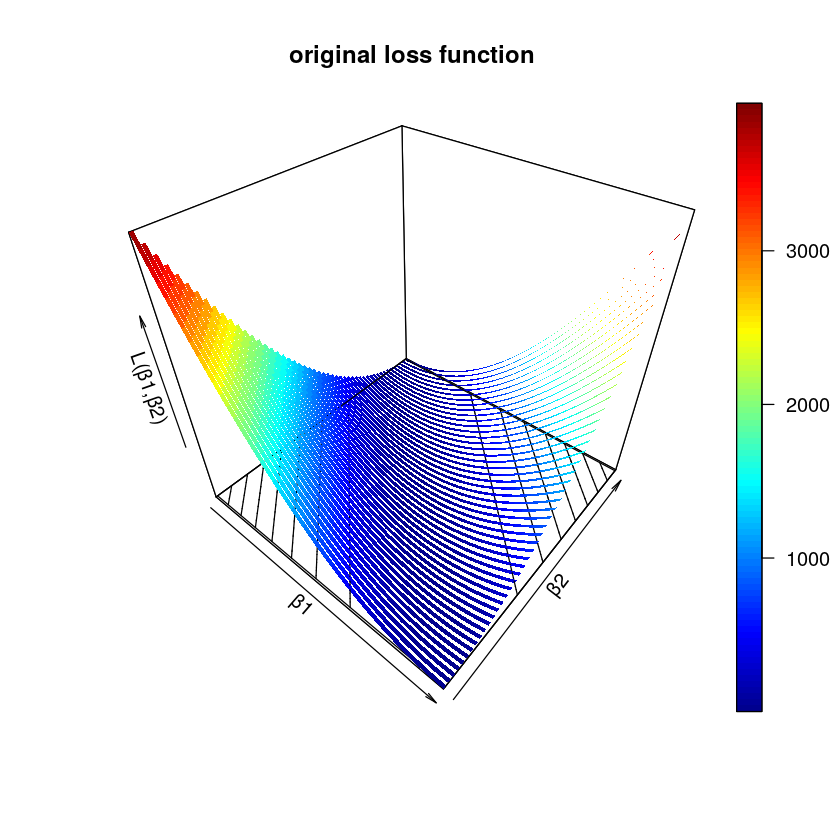

In [46]:
#collapse-hide
β1 = seq(-10,15,length=50)
β2 = seq(-10,15,length=50)
L_ <- function(β1,β2){
    rtn<-c()
    for(k in 1:length(β2)){
        rtn[k]<-sum((y-β1[k]*toeic-β2[k]*teps)^2)/c
    }
    rtn
}
z_=outer(β1,β2,L_)
library(plot3D) 
ribbon3D(z=z_,contour=TRUE,xlab="β1",ylab="β2",zlab="L(β1,β2)",main="original loss function")

보는것처럼 $\beta_1+\beta_2 \approx 5$ 근처에서 작은 $L(\beta_1,\beta_2)$값을 가진다. 

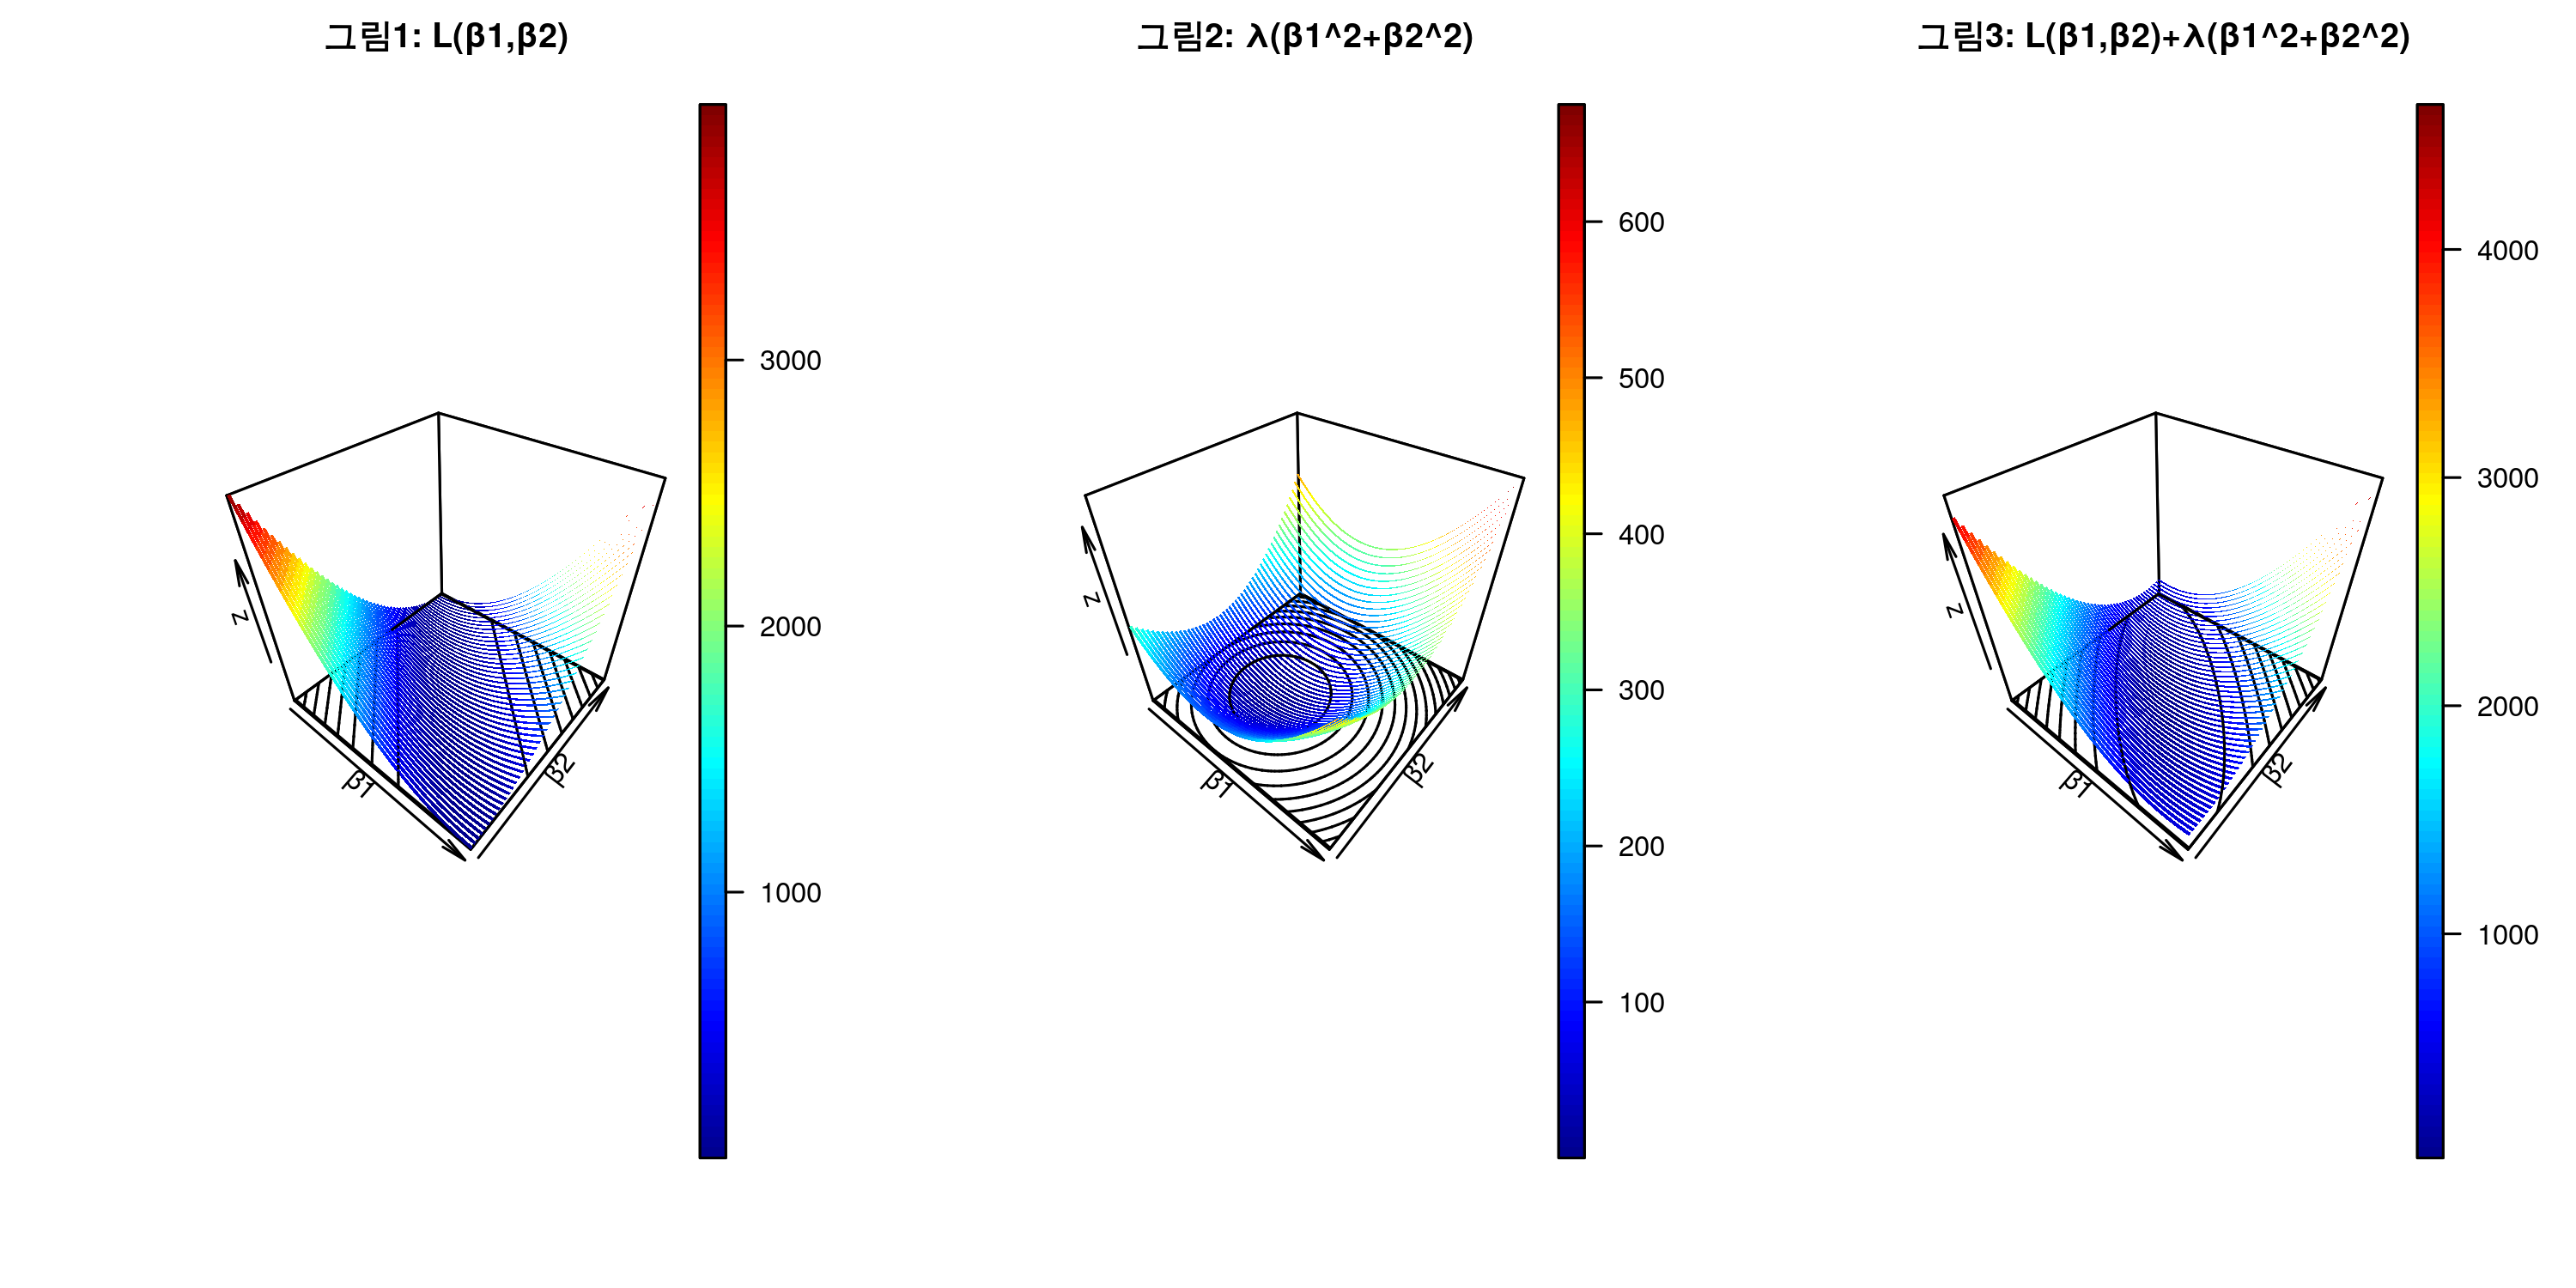

In [50]:
#collapse-hide
options(repr.plot.width=10, repr.plot.height=5,repr.plot.res=300)
β1 = seq(-10,15,length=50)
β2 = seq(-10,15,length=50)
panelty_<-function(β1,β2){
    λ<-1.5 # 1/100000
    rtn<-c()
    for(k in 1:length(β2)){
        rtn[k]<-λ*sum(β1[k]^2+β2[k]^2)
    }
    rtn    
}

L_ <- function(β1,β2){
    rtn<-c()
    for(k in 1:length(β2)){
        rtn[k]<-sum((y-β1[k]*toeic-β2[k]*teps)^2)/c
    }
    rtn
}
z_=outer(β1,β2,L_)
z__=outer(β1,β2,panelty_)
library(plot3D) 
par(mfrow=c(1,3))
ribbon3D(z=z_,contour=TRUE,xlab="β1",ylab="β2",main="그림1: L(β1,β2)")
ribbon3D(z=z__,contour=TRUE,xlab="β1",ylab="β2",main="그림2: λ(β1^2+β2^2)")
ribbon3D(z=z_+z__,contour=TRUE,xlab="β1",ylab="β2",main="그림3: L(β1,β2)+λ(β1^2+β2^2)")
par(mfrow=c(1,1))

### $\lambda$의 역할 $(\lambda>0)$

[그림1]이랑 [그림2]을 섞어서 [그림3]을 만드는데, 각각을 얼만큼의 비율로 섞을지 결정한다. 

람다가 크면 그림2를 많이 반영한다. $\to$ 람다가 너무 크면 결국 $\hat{\beta}_1$와 $\hat{\beta}_2$의 추정값이 거의 0에 가깝게 된다. 

람다가 작으면 그림1을 많이 반영한다. $\to$ 람다가 너무 작게되면, 우리는 손실함수 $L(\beta_1,\beta_2)$에 아무런 수정도 하지않은 셈이된다. 

### $\lambda(\beta_1^2+\beta_2^2)$의 역할

원래 $\beta_1+\beta_2=5$를 만족하는 어떠한 해도 솔루션이 되었음. 즉 [그림1]과 같은 상황

[그림1]과 같은 상황에서 약간의 경사를 주어서 [그림3]과 같은 상황을 만듬 

$\hat{\beta}_1$ 와 $\hat{\beta}_2$ 의 값을 안정적으로 만들어 준다. 

그러면서도 딱히 원래 $L(\beta_1,\beta_2)$의 모양을 크게 해치지 않는다. 

(!) 그럴듯함. 우리가 원하는것 같다. 

이렇게 하면 다중공선성이 발생하는 상황에서 적절한 해를 구할 수 있을 것 같다. 

(관찰)

$\lambda\big(\beta_1^2+\beta_2^2\big)$은 아래와 같이 표현가능함. 

$\lambda [\beta_1,\beta_2]\begin{bmatrix}\beta_1 \\ \beta_2 \end{bmatrix}=\lambda\beta^\top \beta$

단, $\beta=\begin{bmatrix}\beta_1 \\ \beta_2 \end{bmatrix}$.

### 릿지에 대한 책의 설명들.. 

Step 1. $\hat{\beta}^R=\bf\big(X^\top X+\lambda I \big)^{-1}{\bf X}^\top y$. 

일반적인 회귀분석과 다르게 아래와 같은 손실함수를 생각하자. 

$L={\bf (y-X\beta)^\top}{\bf (y-X\beta)}+\lambda \beta^\top \beta=\mbox{goodness of fit} + \mbox{panalty}$

$L$를 최소화하는 $\hat{\beta}$을 구하면 아래와 같다. 구분을 위해서 $\hat{\beta}^R$이라는 기호를쓰자.

$\hat{\beta}^R=\bf\big(X^\top X+\lambda I \big)^{-1}{\bf X}^\top y$

Step 2 : $\hat{\beta}^R$이 $\hat{\beta}^{OLS}$보다 왜 좋은가?

$\hat{\beta}^{OLS}={\bf (X^\top X)^{-1}X^\top y}$

$\hat{\beta}^{R}={\bf (X^\top X+\lambda I)^{-1}X^\top y}$

(1) $\hat{\beta}^{OLS}$는 $\beta$에 대한 불편추정량 이지만, $\hat{\beta}^{R}$은 아니다.  

(2) 하지만 분산은 $\hat{\beta}^{OLS}$보다 $\hat{\beta}^R$이 더 작다.

(3) 좋은 추정량은 bias와 분산이 모두 작아야하는데, $\hat{\beta}^{R}$은 바이어스는 $\hat{\beta}^{OLS}$보다 큰 상황이고, 분산은 $\hat{\beta}^{OLS}$보다 작은 상황이다. 

(4) 따라서 두 추정치중에서 뭐가 더 좋다고 말하기 애매한데, 이를 명확하게 말하기 위해서는 MSE($=\mbox{bias}^2 + \mbox{variance}$)를 비교해봐야한다. 


(5) Hoerl 과 Kennard는 $\hat{\beta}^{R}$이 $\hat{\beta}^{OLS}$보다 MSE가 작게되는 $\lambda$값이 항상 존재한다고 한다고 밝혔다. (1970년)


(6) 따라서 이러한 $\lambda$를 잘 찾으면 항상 Ridge Regression이 Linear Regression 보다 좋다고 주장할 수 있다.  

(참고)

(1) 일반적인 손실함수 $L={\bf (y-X\beta)^\top (y-X\beta)}$와 수정된 손실함수를 구분하기 위해서 아래와 같이 $\tilde{L}$와 같은 기호를 쓰기도 한다. 

$\tilde{L}={\bf(y-X\beta)^\top(y-X\beta)+\lambda \beta^\top \beta }$

(2) 일반적인 손실함수 $L$을 최소화하는 $\beta$와 수정된 손실함수 $\tilde{L}$을 최소화하는 $\beta$를 구분하기 위해서 아래와 같은 기호를 쓰기도 한다. 

$\hat{\beta}^{OLS}={\bf (X^\top X)^{-1}X^\top y}$

$\hat{\beta}^{R}={\bf (X^\top X+\lambda I)^{-1}X^\top y}$

(3) $\lambda \beta^\top \beta$를 패널티항(=벌점항), $L_2$-패널티, regularization term (정규화항) 이라고 부른다. 

(4) $\lambda \beta^\top \beta$를 $\lambda \|\beta\|_2^2$로 표현하기도 한다. $\| \cdot \|_2$는 벡터의 $L_2$-노름 이라고 한다. 

- ${\bf x}=(x_1,x_2)$ $\to$ $\|{\bf x}\|_2^2:=x_1^2+x_2^2$,  $\|{\bf x}\|_2:=\sqrt{x_1^2+x_2^2}$
- $\lambda \beta^\top \beta = \lambda(\beta_1^2+\beta_2^2)$

(5) (4)에서 유리하여 $\lambda \beta^\top \beta$를 $L_2$-패널티항이라고 부르기도 한다. 

(6) 참고로 $L_1$-패널티항도 있다. 그리고 $L_1$과 $L_2$패널티를 섞어서 쓰는 방법도 있다. 
- $Loss=SSE+L_2\mbox{-}panalty$: Ridge
- $Loss=SSE+L_1\mbox{-}panalty$: Lasso
- $Loss=SSE+L_1\mbox{-}panalty+L_2\mbox{-}panalty$: Elastic-net 

(7) $L_2$-패널티항은 너무 큰 $\beta_1,\beta_2$를 구할때 패널티를 부여하여 되도록이면 작은 $\beta_1,\beta_2$을 선택하게끔 `제약`을 건다. 

(8) 일반적인 손실함수 $L$이지만 우리는  $\tilde{L}$을 최소화해야 하므로 (i) 되도록이면 $\beta_1,\beta_2$의 값이 작을수록 좋다는 제약하에서 (ii) $L$를 최소화하는 2가지 역할을 수행해야 한다. 

(9) $\tilde{L}$를 최소화하는 문제를 `제약된 조건하에서의 최소화문제`라고 표현한다. 

(10) (8)에서 (i)-(ii)의 역할중에서 어떤것을 더 중시할지 조율하는 역할을 $\lambda$가 하는데, 이와 같은 이유로 $\lambda$를 조율모수 (tuning parameter)라고 부르기도 한다. 

(11) $\lambda$를 하이퍼파라메터라고 부르기도 한다. 

(12) $\hat{\beta}^{R}$의 값은 대체적으로 $\hat{\beta}^{OLS}$보다 작은값을 가진다. 이러한 이유로 $\beta^{R}$ shrinkage esitmator라고 부른다. 

(13) biased regression, shrinkage method, regularization method, panalty method.. 등 ridge를 표현하는 방법들은 다양하다. 

(14) 능형회귀를 수행함에 있어서 (이론적인 부분에서는 언급되지 않았으나) 변수의 표준화를 먼저 시행해야 한다. 